<a href="https://colab.research.google.com/github/airctic/icevision/blob/master/notebooks/getting_started_instance_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started with Instance Segmentation using IceVision

## Introduction

This tutorial walk you through the different steps of training the fridge dataset. the IceVision Framework is an **agnostic framework**. As an illustration, we will train our model using both the [fastai](https://github.com/fastai/fastai) library, and [pytorch-lightning](https://github.com/PyTorchLightning/pytorch-lightning) libraries.

For more information about how the fridge dataset as well as its corresponding parser check out the [pennfudan folder](https://github.com/airctic/icedata/tree/master/icedata/datasets/pennfudan) in icedata.

## Installing IceVision and IceData
If on Colab run the following cell, else check the [installation instructions](https://airctic.com/dev/install/)

Install from pypi...

In [ ]:
# # IceVision - IceData - MMDetection - YOLO v5 Installation
# !wget https://raw.githubusercontent.com/airctic/icevision/master/icevision_install.sh

# # Choose your installation target: cuda11 or cuda10 or cpu
# !bash icevision_install.sh cuda11

... or from icevision master

In [ ]:
# Torch - Torchvision - IceVision - IceData - MMDetection - YOLOv5 - EfficientDet Installation
!wget https://raw.githubusercontent.com/airctic/icevision/master/icevision_install.sh

# Choose your installation target: cuda11 or cuda10 or cpu
!bash icevision_install.sh cuda11 master

In [ ]:
# Restart kernel after installation
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

## Imports

In [1]:
from icevision.all import *

INFO     - The mmdet config folder already exists. No need to downloaded it. Path : /home/dnth/.icevision/mmdetection_configs/mmdetection_configs-2.16.0/configs | icevision.models.mmdet.download_configs:download_mmdet_configs:17


### Alternative option of importing icevision

In some environments wildcard imports are not allowed (eg: Kubeflow Pipelines & distributed environment that rely on pickling). 

In that case you can call `import icevision.all as iv`  instead of `from icevision.all import *`

In that case you should reference icevision objects with the `iv.` prefix, so for instance one would do `iv.Dataset` instead of the regular approach of just doing `Dataset`, same for any other icevision object (eg: `iv.tfms.A.Adapter` instead of `tfms.A.Adapter` etc).

## Model
To create a model, we need to:

* Choose one of the **models** supported by IceVision
* Choose one of the **backbones** corresponding to a chosen model
* Determine the **number of the object classes**: This will be done after parsing a dataset. Check out the Parsing Section 

## Choose a model and backbone

We use **MMDet** here. When you want to use the torch vision version the COCOMetric will not be correct at the moment due to a problem in the bounding box conversion.

In [1]:
from icevision import models

In [2]:
# Just change the value of selection to try another model

selection = 3

if selection == 0:
    model_type = models.mmdet.mask_rcnn
    backbone = model_type.backbones.resnet50_fpn_1x
    
if selection == 1:
    model_type = models.mmdet.mask_rcnn
    backbone = model_type.backbones.mask_rcnn_swin_t_p4_w7_fpn_1x_coco

if selection == 2:
    model_type = models.mmdet.yolact
    backbone = model_type.backbones.r101_1x8_coco

if selection == 3:
    model_type = models.torchvision.mask_rcnn
    backbone = model_type.backbones.resnet18_fpn

## Datasets : Pennfudan
Fridge Objects dataset is tiny dataset that contains 134 images of 4 classes:
- can, 
- carton, 
- milk bottle, 
- water bottle.

IceVision provides very handy methods such as loading a dataset, parsing annotations, and more. 

In [3]:
import icedata

In [33]:
data_dir

Path('/home/ppotrykus/.icevision/data/PennFudanPed')

In [4]:
# Loading Data
data_dir = icedata.pennfudan.load_data()
parser = icedata.pennfudan.parser(data_dir)

In [5]:
# train_ds, valid_ds = icedata.pennfudan.dataset(data_dir)
train_rs, valid_rs = parser.parse()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170/170 [00:00<00:00, 3829.59it/s]
INFO     - Autofixing records | icevision.parsers.parser:parse:135
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170/170 [00:00<00:00, 21694.46it/s]


In [6]:
from icevision import tfms

In [7]:
# Transforms
image_size = 512
train_tfms = tfms.A.Adapter([*tfms.A.aug_tfms(size=image_size, presize=1024), tfms.A.Normalize()])
valid_tfms = tfms.A.Adapter([*tfms.A.resize_and_pad(image_size), tfms.A.Normalize()])

In [8]:
from icevision.data.dataset import Dataset

In [9]:
train_ds = Dataset(train_rs, train_tfms)
valid_ds = Dataset(valid_rs, valid_tfms)

### Displaying the same image with different transforms

Note:
> Transforms are applied **lazily**, meaning they are only applied when we grab (get) an item.
> This means that, if you have augmentation (random) transforms, each time you get the **same** item from 
> the dataset you will get a slightly different version of it.

In [10]:
from icevision.visualize.show_data import show_samples

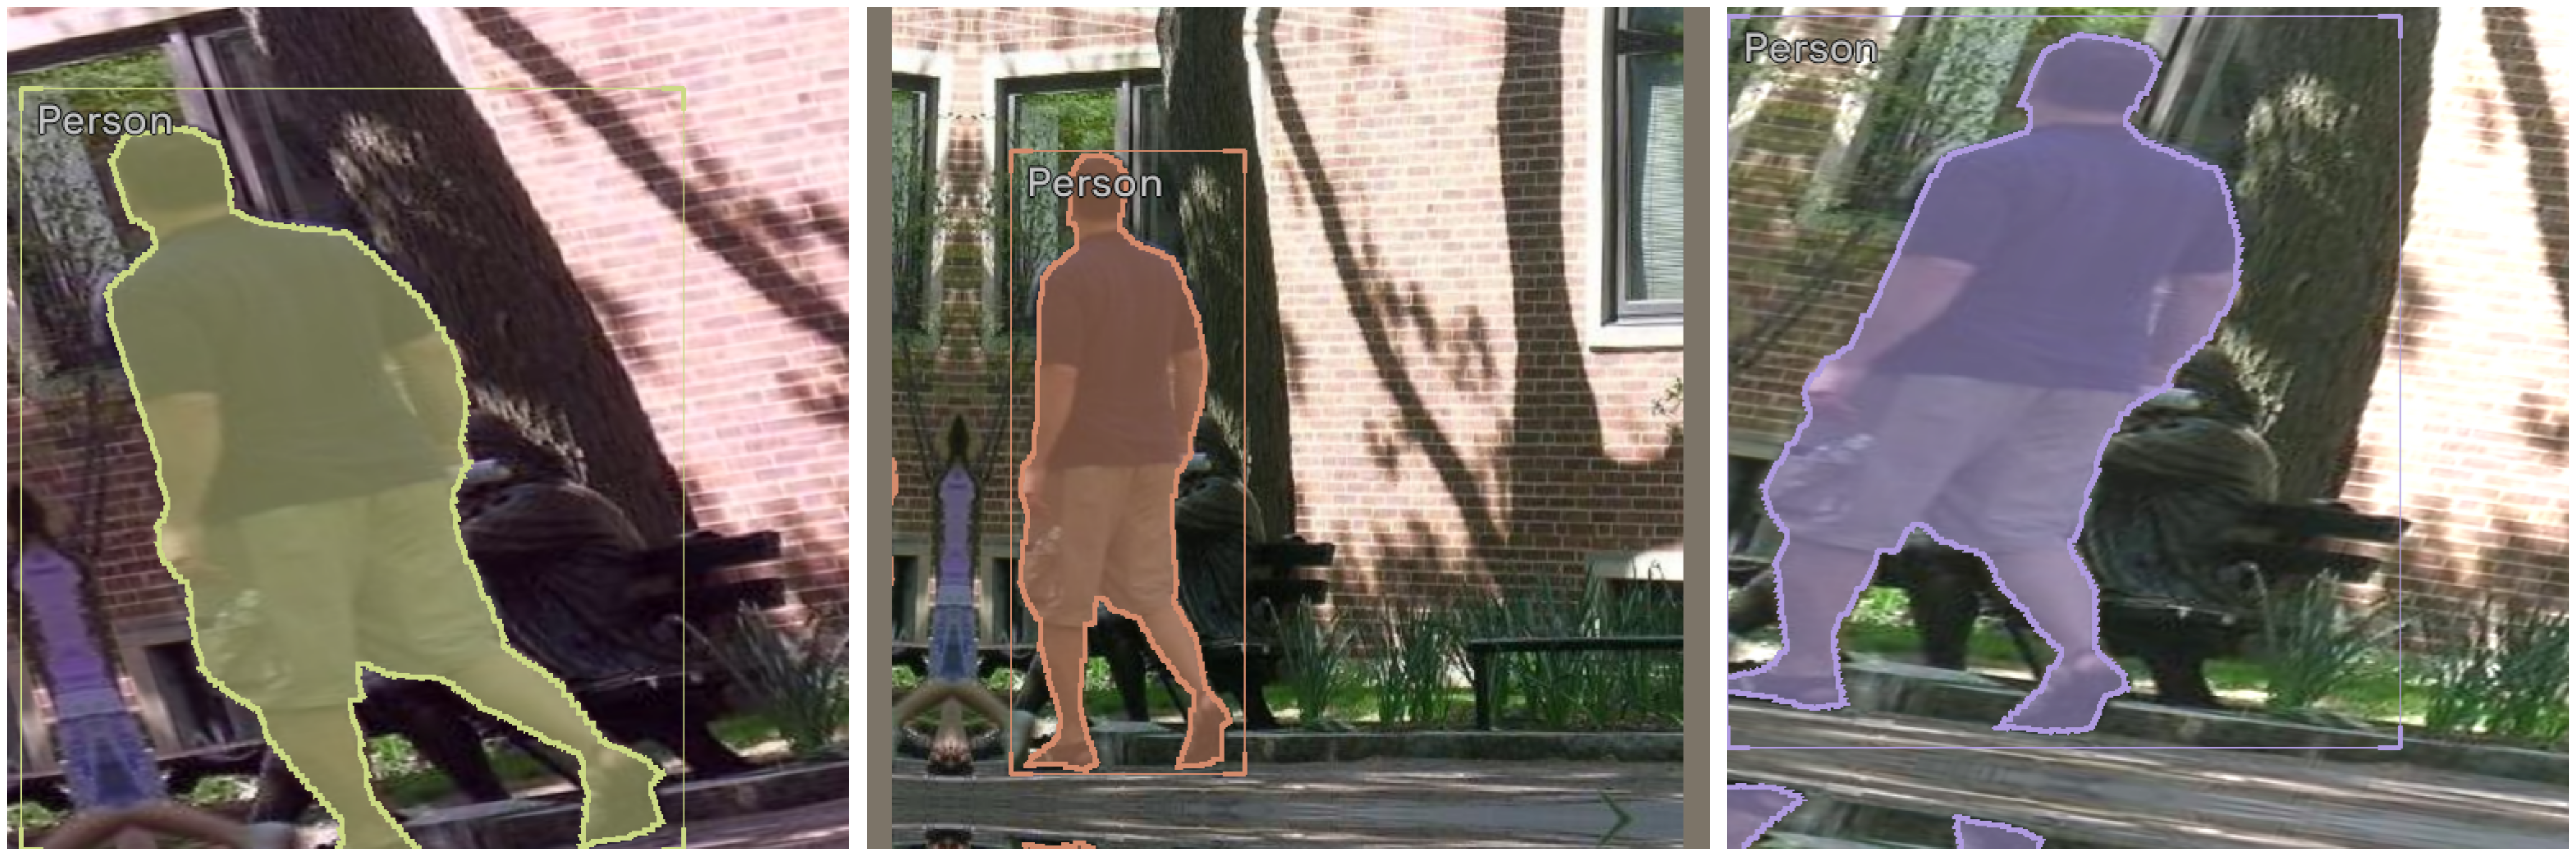

In [11]:
samples = [train_ds[0] for _ in range(3)]
show_samples(samples, ncols=3)

## DataLoader

In [12]:
# DataLoaders
train_dl = model_type.train_dl(train_ds, batch_size=4, num_workers=4, shuffle=True)
valid_dl = model_type.valid_dl(valid_ds, batch_size=4, num_workers=4, shuffle=False)

In [13]:
infer_dl = model_type.infer_dl(valid_ds, batch_size=8, shuffle=False)

In [14]:
valid_batch = first(valid_dl)
infer_batch = first(infer_dl)

NameError: name 'first' is not defined

In [15]:
# show batch
model_type.show_batch(first(valid_dl), ncols=4)

NameError: name 'first' is not defined

## Model

Now that we determined the number of classes (`num_classes`), we can create our `model` object.

In [16]:
# TODO: Better flow for train_ds
model = model_type.model(backbone=backbone(pretrained=True), num_classes=icedata.pennfudan.NUM_CLASSES) 

/home/ppotrykus/Programs/icevision/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ppotrykus/Programs/icevision/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Metrics

In [18]:
from icevision.metrics.coco_metric.coco_metric import COCOMetricType, COCOMetric

In [19]:
metrics = [COCOMetric(metric_type=COCOMetricType.mask)]

## Training

IceVision is an agnostic framework meaning it can be plugged to other DL framework such as [fastai2](https://github.com/fastai/fastai2), and [pytorch-lightning](https://github.com/PyTorchLightning/pytorch-lightning).  

You could also plug to oth DL framework using your own custom code.

### Training using fastai

In [28]:
learn = model_type.fastai.learner(dls=[train_dl, valid_dl], model=model, metrics=metrics)

SuggestedLRs(valley=0.0004786300996784121)

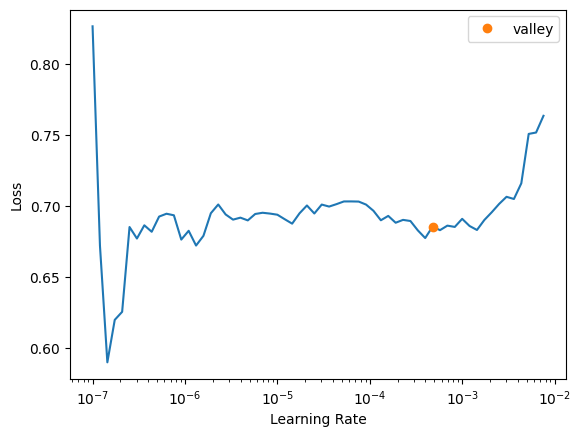

In [29]:
learn.lr_find()

In [30]:
learn.fine_tune(5, 3e-4, freeze_epochs=2)

epoch,train_loss,valid_loss,COCOMetric,time
0,0.658611,0.720068,0.012019,00:05
1,0.647967,0.705070,0.012860,00:05


epoch,train_loss,valid_loss,COCOMetric,time
0,0.605480,0.682604,0.011843,00:06
1,0.618030,0.652699,0.005697,00:06
2,0.610000,0.655503,0.006139,00:07
3,0.596953,0.649622,0.011463,00:07
4,0.585105,0.652820,0.012790,00:07


### Training using Lightning

In [26]:
import lightning.pytorch as L
from torch.optim import AdamW


class LightModel(model_type.lightning.ModelAdapter):
    def configure_optimizers(self):
        return AdamW(self.parameters(), lr=5e-4)
    
light_model = LightModel(model, metrics=metrics)

In [27]:
trainer = L.Trainer(max_epochs=5, accelerator='gpu')
trainer.fit(light_model, train_dl, valid_dl)

INFO: GPU available: True (cuda), used: True
11/06/2024 09:28:42 - INFO - lightning.pytorch.utilities.rank_zero -   GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
11/06/2024 09:28:42 - INFO - lightning.pytorch.utilities.rank_zero -   TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
11/06/2024 09:28:42 - INFO - lightning.pytorch.utilities.rank_zero -   HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
11/06/2024 09:28:42 - INFO - lightning.pytorch.accelerators.cuda -   LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | MaskRCNN | 30.9 M | train
-------------------------------------------
30.7 M    Trainable params
156 K     Non-trainable params
30.9 M    Total params
123.588   Total estimated model params size (MB)
124       Modules in train mode
0         Modules in eval mode
11/06/2024 09:

Sanity Checking: |                                                                                            …

/home/ppotrykus/Programs/icevision/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 3. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/ppotrykus/Programs/icevision/.venv/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (34) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
11/06/2024 09:29:20 - INFO - lightning.pytorch.utilities.rank_zero -   `Trainer.fit` stopped: `max_epochs=5` reached.


## Show Results

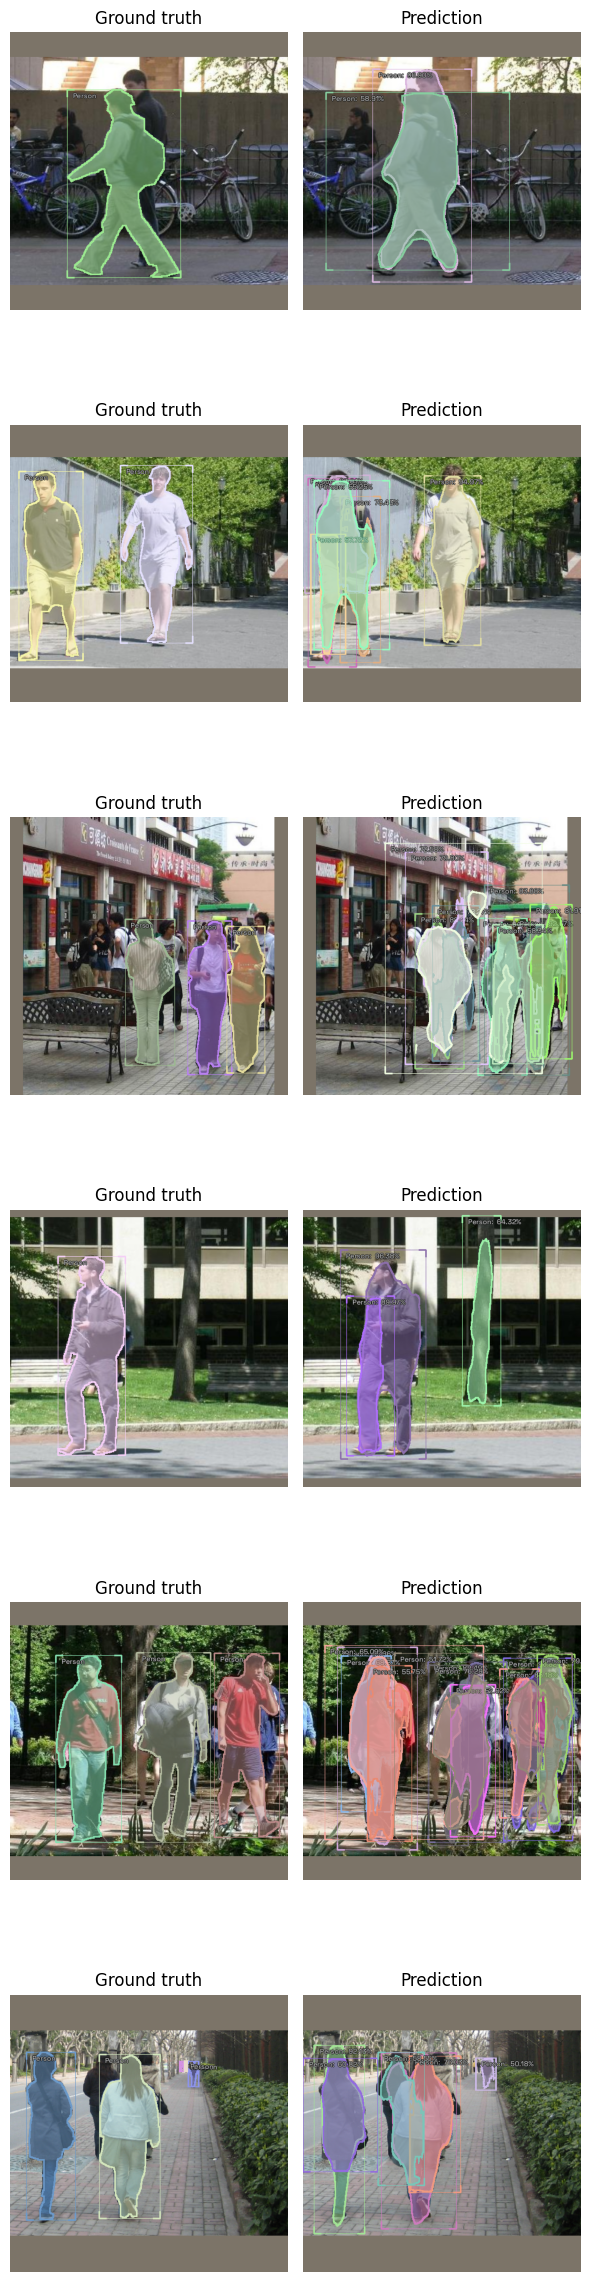

In [31]:
model_type.show_results(model, valid_ds, detection_threshold=.5)

## Inference

### Predicting a batch of images

Instead of predicting a whole list of images at one, we can process small batches at the time: This option is more memory efficient. 


> NOTE: For a more detailed look at inference check out the [inference tutorial](https://airctic.com/dev/inference/)

In [35]:
batch, records = first(valid_dl)

In [36]:
infer_dl = model_type.infer_dl(valid_ds, batch_size=4, shuffle=False)
preds = model_type.predict_from_dl(model, infer_dl, keep_images=True)

  0%|          | 0/9 [00:00<?, ?it/s]

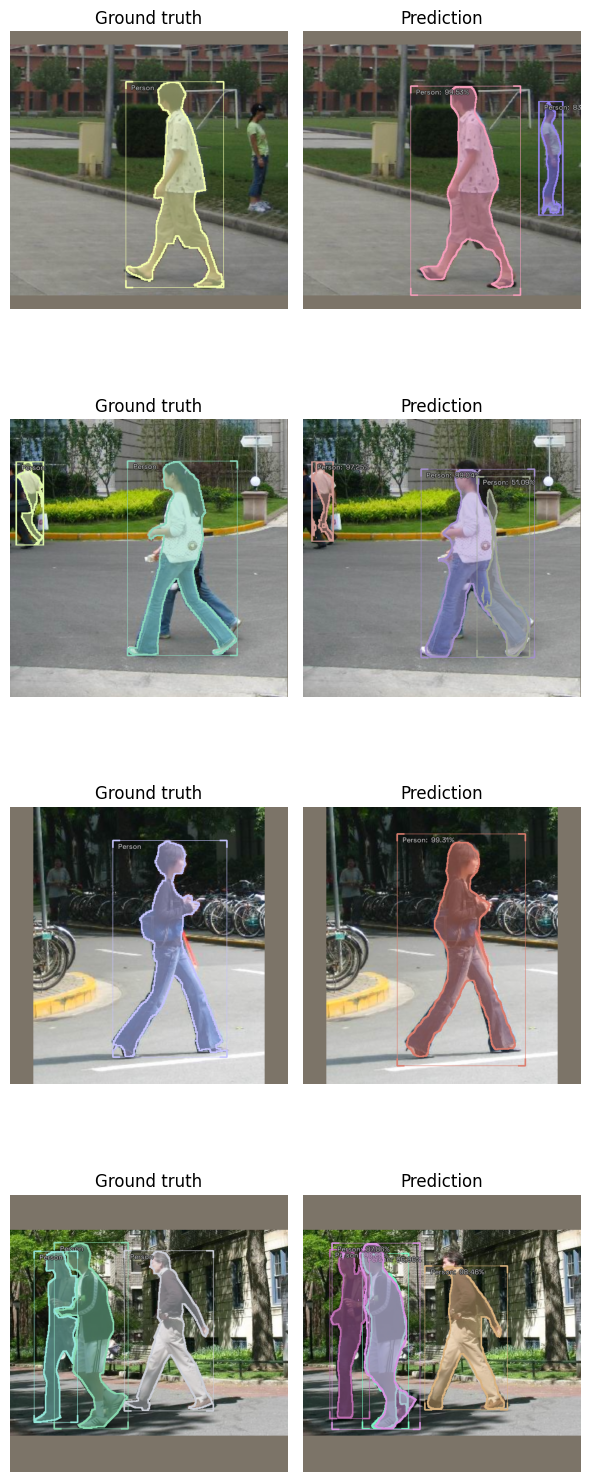

In [37]:
show_preds(preds=preds[:4], ncols=3)

## Happy Learning!

If you need any assistance, feel free to join our [forum](https://discord.gg/JDBeZYK).